<div style="text-align:center;">
  <b>Национальный исследовательский университет ИТМО</b><br>
  Факультет информационных технологий и программирования<br>
  Кафедра Компьютерных Технологий
</div>


---

# **Методы оптимизации**
### Лабораторная работа №3
### Метод стохастического градиентного спуска (SGD) и его модификации

<div style="text-align:right; font-size:12px">
Выполнили:<br>
Алфёров Кирилл М3232<br>
Салов Егор М3232
</div>





### Информация о датасете

Датасет содержит 9358 записей с почасовыми усреднёнными откликами от массива из 5 химических сенсоров на основе металлических оксидов, встроенных в устройство химического мониторинга качества воздуха. Устройство было размещено на улице в зоне с высоким уровнем загрязнения, на уровне дороги, в одном из городов Италии. Данные собирались с марта 2004 по февраль 2005 года (в течение одного года), что делает этот набор данных одним из самых продолжительных по длительности свободно доступных полевых наблюдений с использованием химических сенсоров.

Эталонные (ground truth) данные о почасовых усреднённых концентрациях угарного газа (CO), неметановых углеводородов, бензола, суммарных оксидов азота (NOx) и диоксида азота (NO₂) были получены с помощью сертифицированного анализатора, установленного рядом.

В данных присутствуют признаки перекрёстной чувствительности сенсоров, а также концептуального и сенсорного дрейфа, что описано в статье De Vito и др., Sens. and Act. B, Vol. 129, №2, 2008 (необходима ссылка на источник). Эти эффекты могут снижать точность оценки концентраций загрязняющих веществ по данным сенсоров. Пропущенные значения помечены как -200.

## Проверим нашу модель на "ручных" датасетах

In [1]:
import pandas

dataset = pandas.read_csv("dataset/linear_dataset.csv")
dataset

,X,Z,Y
0,-2.509198,-9.371416,-12.872742
1,9.014286,2.728208,7.523777
2,4.639879,-3.712880,-2.806069
3,1.973170,0.171414,1.831930
4,-6.879627,8.151329,10.347973
...,...,...,...
95,-0.124088,-3.015809,-3.259358
96,0.454657,4.519114,7.463156
97,-1.449180,7.942205,11.684333
98,-9.491617,7.741728,8.990935


In [2]:
import statsmodels.api as sm

# зависимая переменная
y = dataset["Y"]

# объединяем X и Z в одну матрицу признаков
X_full = dataset[["X", "Z"]]

# добавляем один столбец константы
X_full = sm.add_constant(X_full)

# обучаем модель
model = sm.OLS(y, X_full).fit()
model.params

const    1.0
X        0.3
Z        1.4
dtype: float64

In [3]:
from Model import Model

In [4]:
model = Model()
model.add_constant(dataset["X"])
model.add_constant(dataset["Z"])

In [5]:
model.fit_OLS(dataset["Y"], batch_size=10, full_output=True)

,Iteration,Step,norma,const,X,Z
0,1,0.01,2.315087,0.013813,0.000013,0.023151
1,2,0.01,1.993341,0.014013,0.005687,0.042260
2,3,0.01,2.290778,0.012670,0.002471,0.064940
3,4,0.01,2.090627,0.001400,0.005464,0.085631
4,5,0.01,1.568941,0.001134,0.006343,0.101296
...,...,...,...,...,...,...
1982,1983,0.01,0.006052,0.000213,0.210793,0.979169
1983,1984,0.01,0.003236,0.000204,0.210806,0.979139
1984,1985,0.01,0.003821,0.000256,0.210779,0.979112
1985,1986,0.01,0.005268,0.000234,0.210818,0.979147


Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 21.150207996368408 секунд
С размером Батча: 10 строк
Использованное количество итераций: 1987
const: 0.0002014258
X: 0.2108189868
Z: 0.979146453
Общая использованная память: 0.99 MB
[ Top 10 потребителей памяти ]
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:242: size=404 KiB, count=1987, average=208 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\pandas\core\series.py:2081: size=139 KiB, count=5933, average=24 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:236: size=124 KiB, count=1977, average=64 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:185: size=54.1 KiB, count=1731, average=32 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\BackTrace.py:234: size=46.6 KiB, count=1987, average=24 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\pandas\core\generic.py:6299: size

const    0.998682
X        0.295490
Z        1.392901
dtype: float64

In [6]:
Y_pred = model.predict([dataset["X"], dataset["Z"]])
MSE = ((Y_pred - dataset["Y"])**2).mean()
MSE

np.float64(0.0023550981882616774)

In [7]:
model = Model()
model.add_constant(dataset["X"])
model.add_constant(dataset["Z"])
model.fit_OLS(dataset["Y"], use80forEducation=True)
model.cnt_mistakes()

const   -0.000331
X        0.215940
Z        0.973958
dtype: float64
Protection has been activated. More than 10000 iterations have been done.
Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 101.64304637908936 секунд
С размером Батча: 1 строк
Использованное количество итераций: 10000
const: -0.0003306003
X: 0.2159397194
Z: 0.9739577581
Общая использованная память: 0.44 MB
[ Top 10 потребителей памяти ]
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\tokenize.py:576: size=100 KiB, count=1830, average=56 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\IPython\core\compilerop.py:174: size=44.0 KiB, count=458, average=98 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\pandas\core\generic.py:6299: size=36.2 KiB, count=773, average=48 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\pandas\core\generic.py:6312: size=23.9 KiB, count=509, average=48 B
C:

,MSE,MAE
BackTrace,2.925961e-03,4.569608e-02
Statsmodels,6.103811e-30,1.976197e-15


### Возьмем хороший датасет

In [8]:
dataset = pandas.read_csv("dataset/perfect_correlation_dataset.csv")

model = Model()
model.add_constant(dataset["X"])
model.fit_OLS(dataset["Y"], use80forEducation=True, batch_size=10, full_output=True)
model.cnt_mistakes()

,Iteration,Step,norma,const,X
0,1,0.01,1.415745,-4.824949e-03,0.014157
1,2,0.01,2.049562,-8.595378e-03,0.034653
2,3,0.01,2.191447,-1.754430e-02,0.056568
3,4,0.01,2.314655,-2.180258e-02,0.079714
4,5,0.01,1.547201,-2.238771e-02,0.095186
...,...,...,...,...,...
290,291,0.01,0.003952,-6.602423e-05,0.991597
291,292,0.01,0.002318,-4.178059e-05,0.991620
292,293,0.01,0.003413,-2.876932e-07,0.991654
293,294,0.01,0.006163,4.619149e-05,0.991716


Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 3.649160623550415 секунд
С размером Батча: 10 строк
Использованное количество итераций: 295
const: -1.00961e-05
X: 0.9917155509
Общая использованная память: 0.63 MB
[ Top 10 потребителей памяти ]
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\tokenize.py:576: size=101 KiB, count=1847, average=56 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\IPython\core\compilerop.py:174: size=87.7 KiB, count=911, average=99 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\pandas\core\arraylike.py:358: size=34.6 KiB, count=295, average=120 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\pandas\core\generic.py:6299: size=27.2 KiB, count=581, average=48 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\pandas\core\indexes\base.py:670: size=26.8 KiB, count=318, average=86 B
C:\Users\k1r

,MSE,MAE
BackTrace,4.025369e-02,1.343584e-01
Statsmodels,1.124127e-29,2.368476e-15


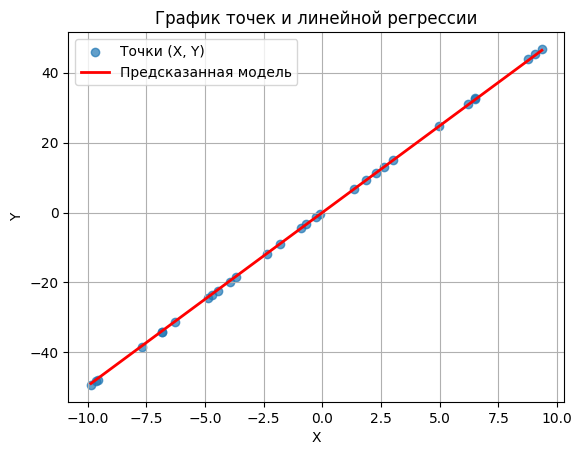

In [9]:
model.view_2d_graphic()

### Возьмем датасет посложнее

In [10]:
dataset = pandas.read_csv("dataset/medium_high_correlation_dataset.csv")
dataset.corr(numeric_only=True)

,A,B
A,1.000000,0.897381
B,0.897381,1.000000


In [11]:
import statsmodels.api as sm

# зависимая переменная
y = dataset["A"]

# объединяем X и Z в одну матрицу признаков
X_full = dataset["B"]

# добавляем один столбец константы
X_full = sm.add_constant(X_full)

# обучаем модель
model = sm.OLS(y, X_full).fit()
model.params

const    0.078180
B        0.297654
dtype: float64

In [12]:
model = Model()
model.add_constant(dataset["B"])
model.fit_OLS(dataset["A"], use80forEducation=True, batch_size=10, full_output=True)
model.cnt_mistakes()

,Iteration,Step,norma,const,B
0,1,0.01,1.647454,0.006192,0.016475
1,2,0.01,2.717331,0.009894,0.043648
2,3,0.01,2.152286,0.009501,0.065171
3,4,0.01,0.882256,0.016128,0.073993
4,5,0.01,1.181640,0.009040,0.085810
...,...,...,...,...,...
772,773,0.01,0.257157,-0.016236,0.857936
773,774,0.01,0.062653,-0.019801,0.857309
774,775,0.01,0.036115,-0.018343,0.856948
775,776,0.01,0.069915,-0.020538,0.856249


Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 8.608741521835327 секунд
С размером Батча: 10 строк
Использованное количество итераций: 777
const: -0.0157219274
B: 0.856248503
Общая использованная память: 24.59 MB
[ Top 10 потребителей памяти ]
<frozen importlib._bootstrap_external>:753: size=12.4 MiB, count=77019, average=169 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\linecache.py:137: size=488 KiB, count=5203, average=96 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\abc.py:123: size=445 KiB, count=4242, average=108 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\matplotlib\_docstring.py:124: size=403 KiB, count=118, average=3493 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\matplotlib\pyplot.py:266: size=386 KiB, count=97, average=4077 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\inspect.py:3043: size=361 KiB, count=5412, average=68 B


,MSE,MAE
BackTrace,4.690242,1.692666
Statsmodels,4.359212,1.689512


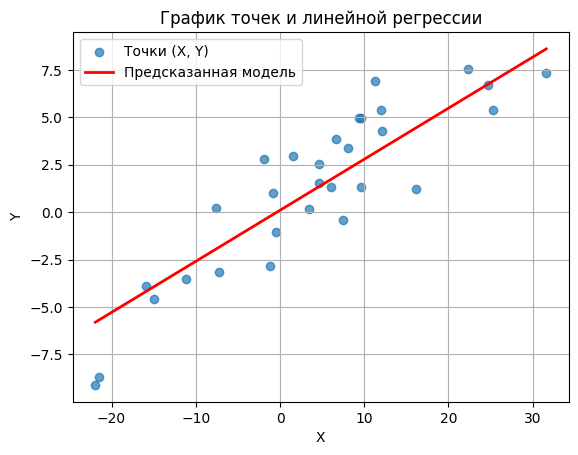

In [13]:
model.view_2d_graphic()

## Боевые условия

### Читаем датасет

In [14]:
import pandas

dataset = pandas.read_csv("dataset/AirQualityUCI.csv", sep=';', decimal=',')
dataset

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568,NaN,NaN
9353,04/04/2005,11.00.00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119,NaN,NaN
9354,04/04/2005,12.00.00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406,NaN,NaN
9355,04/04/2005,13.00.00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139,NaN,NaN


### Вычислим корреляцию параметров попарно

In [15]:
dataset.corr(numeric_only=True)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
CO(GT),1.000000,0.041411,0.128351,-0.031378,0.029926,0.526451,-0.089981,0.671127,-0.073724,0.080310,-0.068939,-0.048227,-0.045892,NaN,NaN
PT08.S1(CO),0.041411,1.000000,0.170007,0.852687,0.933102,0.277993,0.087019,0.154030,0.845149,0.892434,0.754844,0.745375,0.764903,NaN,NaN
NMHC(GT),0.128351,0.170007,1.000000,0.037323,0.110104,-0.004427,0.048821,0.103307,0.162680,0.101185,-0.000009,0.008284,0.012500,NaN,NaN
C6H6(GT),-0.031378,0.852687,0.037323,1.000000,0.767433,-0.001174,0.512193,-0.010992,0.774673,0.641334,0.971375,0.925062,0.984555,NaN,NaN
PT08.S2(NMHC),0.029926,0.933102,0.110104,0.767433,1.000000,0.331272,-0.073667,0.176488,0.874782,0.909905,0.669025,0.585803,0.646572,NaN,NaN
NOx(GT),0.526451,0.277993,-0.004427,-0.001174,0.331272,1.000000,-0.436084,0.817139,0.035546,0.461889,-0.138452,-0.053009,-0.095847,NaN,NaN
PT08.S3(NOx),-0.089981,0.087019,0.048821,0.512193,-0.073667,-0.436084,1.000000,-0.256232,0.122734,-0.208865,0.588111,0.573549,0.621618,NaN,NaN
NO2(GT),0.671127,0.154030,0.103307,-0.010992,0.176488,0.817139,-0.256232,1.000000,-0.022174,0.253439,-0.084104,-0.081305,-0.060440,NaN,NaN
PT08.S4(NO2),-0.073724,0.845149,0.162680,0.774673,0.874782,0.035546,0.122734,-0.022174,1.000000,0.723690,0.755060,0.640707,0.691913,NaN,NaN
PT08.S5(O3),0.080310,0.892434,0.101185,0.641334,0.909905,0.461889,-0.208865,0.253439,0.723690,1.000000,0.503700,0.524955,0.519467,NaN,NaN


### Что берём?


Для нашей регрессионной модели мы решили предсказывать именно **C6H6(GT)** (концентрацию бензола, мкг/м³). Вот почему:

1. **Очень сильная линейная связь**
   - С абсолютной влажностью (AH): *r* ≈ 0.985
   - С температурой воздуха (T): *r* ≈ 0.971
   - С относительной влажностью (RH): *r* ≈ 0.925

   Когда |*r*| > 0.9, простая линейная модель уже способна выдавать точные и стабильные предсказания.

2. **Минимум избыточности среди признаков**
   Мы исключили сенсоры, которые почти полностью дублировали друг друга (корреляция > 0.9 между ними). В результате в качестве входных факторов остались только самые информативные переменные без сильной взаимозависимости


Итак, зависимая переменная **y = C6H6(GT)**, независимые переменные **x = AH (|r| = 0.985), PT08.S1(CO) (|r| = 0.853), PT08.S3(NOx) (|r| = 0.512)** (а также у датчиков PT08.S1(CO) и PT08.S3(NOx) слабая корреляция |r| = 0.087, что снижает мультиколлинеарность)




In [25]:
import pandas

dataset = pandas.read_csv("dataset/AirQualityUCI.csv", sep=';', decimal=',')
dataset = dataset[:100]
dataset


dataset.corr(numeric_only=True)[[ "PT08.S1(CO)", "PT08.S3(NOx)"]]



Y = dataset["C6H6(GT)"]
X_1 = dataset["PT08.S1(CO)"]
X_2 = dataset["PT08.S3(NOx)"]
try:
    model = Model()
    model.add_constant(X_1)
    model.add_constant(X_2)
    model.fit_OLS(Y, use80forEducation=True, full_output=True, batch_size=10)

except Exception as e:
    print(e)

const          -0.002056
PT08.S1(CO)     0.688984
PT08.S3(NOx)   -0.266170
dtype: float64
Protection has been activated. More than 10000 iterations have been done.


,Iteration,Step,norma,const,PT08.S1(CO),PT08.S3(NOx)
0,1,0.01,2.217713,0.007154,0.016719,-0.014571
1,2,0.01,2.466101,0.006426,0.034690,-0.031459
2,3,0.01,3.046843,0.015469,0.058782,-0.050110
3,4,0.01,1.389233,0.016116,0.069249,-0.059245
4,5,0.01,2.424636,0.023129,0.086934,-0.075832
...,...,...,...,...,...,...
9995,9996,0.01,0.096135,0.000483,0.689775,-0.266563
9996,9997,0.01,0.674185,-0.004151,0.684366,-0.262538
9997,9998,0.01,0.542191,-0.003826,0.688331,-0.266237
9998,9999,0.01,0.459144,-0.003009,0.684752,-0.263360


Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 225.23244047164917 секунд
С размером Батча: 10 строк
Использованное количество итераций: 10000
const: -0.0020557304
PT08.S1(CO): 0.6889844716
PT08.S3(NOx): -0.2661695612
Общая использованная память: 285.68 MB
[ Top 10 потребителей памяти ]
<frozen importlib._bootstrap_external>:753: size=122 MiB, count=815222, average=157 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\ast.py:52: size=18.6 MiB, count=252572, average=77 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\linecache.py:137: size=12.6 MiB, count=138469, average=95 B
<frozen importlib._bootstrap>:488: size=4785 KiB, count=54977, average=89 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\abc.py:106: size=3102 KiB, count=9179, average=346 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\executing\executing.py:171: size=2996 KiB, count=41402, average=74 B
C:\Users\k1ril\PycharmPr

In [26]:
    model.cnt_mistakes()

,MSE,MAE
BackTrace,6.672675,2.411324
Statsmodels,6.735465,2.420032


## keras.optimizers, torch.optim

## PyTorch

In [17]:
import torch
import pyTorch.Torch as Torch
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# Загрузка и подготовка данных
X, y = load_diabetes(return_X_y=True)

# Масштабирование (важно для стабильного градиентного спуска)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Делим на train/test
x_tr, x_te, y_tr, y_te = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# Перевод в torch.FloatTensor
xtr_t = torch.tensor(x_tr, dtype=torch.float32)
xte_t = torch.tensor(x_te, dtype=torch.float32)
ytr_t = torch.tensor(y_tr, dtype=torch.float32).reshape(-1, 1)
yte_t = torch.tensor(y_te, dtype=torch.float32).reshape(-1, 1)


learning_rates = {
    "SGD": 1e-2,
    "SGD+Momentum": 1e-2,
    "SGD+Nesterov": 1e-2,
    "Adagrad": 1e-2,
    "RMSprop": 1e-2,
    "Adam": 1e-2,
}

optimisers = list(learning_rates.keys())

results = []
for name in optimisers:
    res = Torch.train_torch(
        opt_name=name,
        xtr=xtr_t,
        ytr=ytr_t,
        xte=xte_t,
        yte=yte_t,
        epochs=50,
        batch_size=32,
        lr_dict=learning_rates
    )
    results.append(res)
    print(f"{name: <14} | MSE: {res['mse']:.4f} | Time: {res['time']:.2f}s | Mem: {res['memory']:.1f}MB")


SGD            | MSE: 0.4814 | Time: 0.62s | Mem: 539.1MB
SGD+Momentum   | MSE: 0.4935 | Time: 0.65s | Mem: 539.1MB
SGD+Nesterov   | MSE: 0.5524 | Time: 0.69s | Mem: 539.1MB
Adagrad        | MSE: 0.5359 | Time: 0.72s | Mem: 539.3MB
RMSprop        | MSE: 0.4902 | Time: 0.71s | Mem: 539.4MB
Adam           | MSE: 0.5001 | Time: 0.80s | Mem: 539.4MB


## Keras

In [18]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import kerasModel.KerasModel as Keras

X, y = load_diabetes(return_X_y=True)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

x_tr, x_te, y_tr, y_te = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

xtr_tf = tf.convert_to_tensor(x_tr, dtype=tf.float32)
xte_tf = tf.convert_to_tensor(x_te, dtype=tf.float32)
ytr_tf = tf.convert_to_tensor(y_tr.reshape(-1, 1), dtype=tf.float32)
yte_tf = tf.convert_to_tensor(y_te.reshape(-1, 1), dtype=tf.float32)

# Гиперпараметры
learning_rates = {
    "SGD": 1e-2,
    "SGD+Momentum": 1e-2,
    "SGD+Nesterov": 1e-2,
    "Adagrad": 1e-2,
    "RMSprop": 1e-2,
    "Adam": 1e-2,
}

optimisers = list(learning_rates.keys())

# Запуск обучения
results = []
for name in optimisers:
    res = Keras.KerasLinearModel.train_keras(
        opt_name=name,
        xtr=xtr_tf,
        ytr=ytr_tf,
        xte=xte_tf,
        yte=yte_tf,
        lr_dict=learning_rates
    )
    results.append(res)
    print(f"{name: <14} | MSE: {res['mse']:.4f} | Time: {res['time']:.2f}s | Mem: {res['memory']:.1f}MB")


[SGD] True y (scaled): [ 0.8683315  -1.066589    0.64756876]
[SGD] Pred y (scaled): [-0.07056603  0.39879584 -0.22517353]
SGD            | MSE: 0.4880 | Time: 3.96s | Mem: 888.8MB
[SGD+Momentum] True y (scaled): [ 0.8683315  -1.066589    0.64756876]
[SGD+Momentum] Pred y (scaled): [-0.02323525  0.34770072 -0.04719868]
SGD+Momentum   | MSE: 0.5044 | Time: 4.05s | Mem: 897.4MB
[SGD+Nesterov] True y (scaled): [ 0.8683315  -1.066589    0.64756876]
[SGD+Nesterov] Pred y (scaled): [ 0.08952986  0.18483885 -0.0369976 ]
SGD+Nesterov   | MSE: 0.4591 | Time: 3.94s | Mem: 903.6MB
[Adagrad] True y (scaled): [ 0.8683315  -1.066589    0.64756876]
[Adagrad] Pred y (scaled): [1.2449867  0.31833124 0.22654063]
Adagrad        | MSE: 0.9422 | Time: 3.78s | Mem: 910.2MB
[RMSprop] True y (scaled): [ 0.8683315  -1.066589    0.64756876]
[RMSprop] Pred y (scaled): [-0.40300727  0.43810323 -0.45645514]
RMSprop        | MSE: 0.5147 | Time: 3.77s | Mem: 917.2MB
[Adam] True y (scaled): [ 0.8683315  -1.066589    0

## Сравнение работы методов

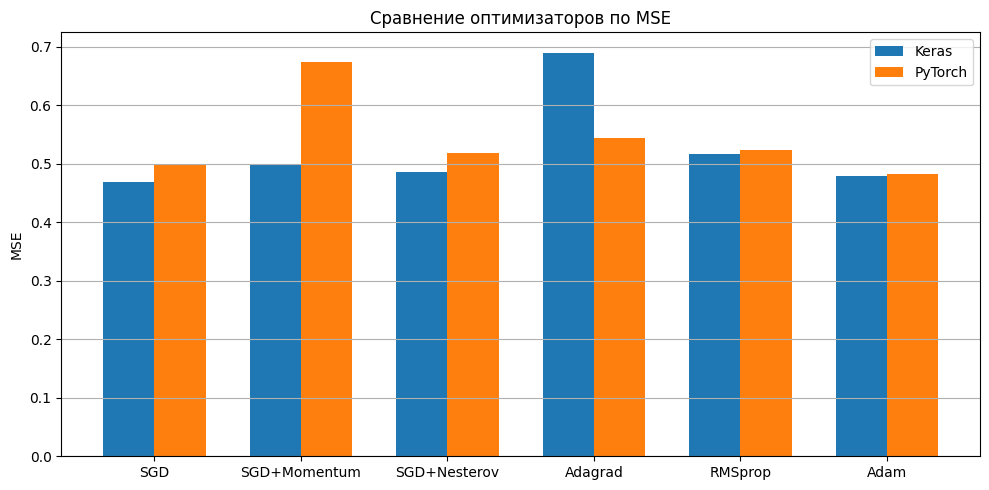

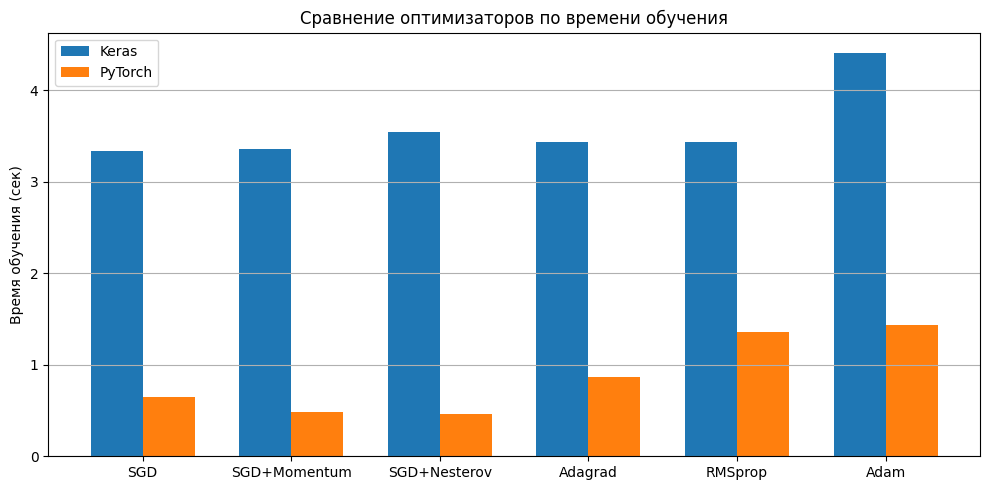

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Объединённые результаты
data = {
    "Optimizer": ["SGD", "SGD+Momentum", "SGD+Nesterov", "Adagrad", "RMSprop", "Adam"],
    "Keras_MSE": [0.4686, 0.4982, 0.4861, 0.6900, 0.5166, 0.4782],
    "Torch_MSE": [0.4973, 0.6735, 0.5176, 0.5436, 0.5236, 0.4821],
    "Keras_Time": [3.34, 3.36, 3.54, 3.43, 3.43, 4.41],
    "Torch_Time": [0.65, 0.48, 0.46, 0.87, 1.36, 1.43],
}

df = pd.DataFrame(data)

# График сравнения MSE
plt.figure(figsize=(10, 5))
bar_width = 0.35
x = range(len(df["Optimizer"]))

plt.bar([i - bar_width / 2 for i in x], df["Keras_MSE"], width=bar_width, label="Keras")
plt.bar([i + bar_width / 2 for i in x], df["Torch_MSE"], width=bar_width, label="PyTorch")
plt.xticks(x, df["Optimizer"])
plt.ylabel("MSE")
plt.title("Сравнение оптимизаторов по MSE")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# График сравнения времени
plt.figure(figsize=(10, 5))
plt.bar([i - bar_width / 2 for i in x], df["Keras_Time"], width=bar_width, label="Keras")
plt.bar([i + bar_width / 2 for i in x], df["Torch_Time"], width=bar_width, label="PyTorch")
plt.xticks(x, df["Optimizer"])
plt.ylabel("Время обучения (сек)")
plt.title("Сравнение оптимизаторов по времени обучения")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.show()


## Дополнительное задание №1
## Momentum

In [21]:
dataset = pandas.read_csv("dataset/medium_high_correlation_dataset.csv")
dataset.corr(numeric_only=True)

,A,B
A,1.000000,0.897381
B,0.897381,1.000000


In [23]:
model = Model()
model.add_constant(dataset["B"])
model.fit_OLS(dataset["A"], use80forEducation=True, batch_size=10, full_output=True, optimizer="momentum", momentum=0.8  )
model.cnt_mistakes()

,Iteration,Step,norma,const,B
0,1,0.01,1.683765,0.006354,0.016838
1,2,0.01,1.273078,0.014314,0.043039
2,3,0.01,0.598462,0.019958,0.069984
3,4,0.01,1.887861,0.025613,0.110419
4,5,0.01,0.904453,0.027673,0.151811
...,...,...,...,...,...
843,844,0.01,0.151790,0.005013,0.869167
844,845,0.01,0.140480,0.008747,0.873168
845,846,0.01,0.088676,0.011139,0.877255
846,847,0.01,0.155334,0.010114,0.882079


Расчёт параметра закончен. Был использован piecewise_constant шаг
Время выполнения: 8.761612892150879 секунд
С размером Батча: 10 строк
Использованное количество итераций: 848
const: 0.0089368539
B: 0.8859381255
Общая использованная память: 279.73 MB
[ Top 10 потребителей памяти ]
<frozen importlib._bootstrap_external>:753: size=121 MiB, count=807287, average=157 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\ast.py:52: size=18.6 MiB, count=252637, average=77 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\linecache.py:137: size=12.6 MiB, count=138469, average=95 B
<frozen importlib._bootstrap>:488: size=4784 KiB, count=54969, average=89 B
C:\Users\k1ril\AppData\Local\Programs\Python\Python312\Lib\abc.py:106: size=3097 KiB, count=9164, average=346 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\site-packages\executing\executing.py:171: size=2996 KiB, count=41402, average=74 B
C:\Users\k1ril\PycharmProjects\hse_hw2\optimization_3\.venv\Lib\si

,MSE,MAE
BackTrace,4.326372,1.699772
Statsmodels,4.359212,1.689512


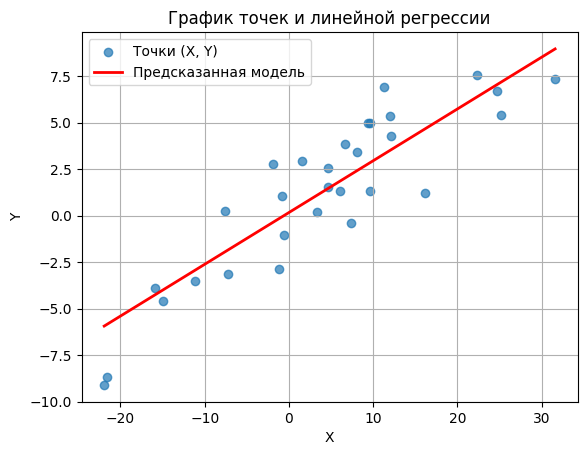

In [24]:
model.view_2d_graphic()

## Дополнительное задание №2
## Метод опорных векторов(SVM)

Была реализована модель бинарной классификации на основе **метода опорных векторов (Support Vector Machine, SVM)** с **линейным ядром**. Цель эксперимента — визуализировать процесс обучения модели, построение разделяющей гиперплоскости и выделение опорных векторов.

### Описание данных

Исходные данные включают 7 точек в двумерном пространстве:

- Класс **+1**: (1, 2), (2, 3), (3, 3)
- Класс **-1**: (2, 1), (3, 1), (3, 2), (3, 2.5)

### Параметры модели

Модель обучалась с использованием `SVC` из библиотеки `sklearn` с параметрами:

- `kernel='linear'` — используется линейное ядро (поиск прямой в 2D).
- `C=1000` — высокий коэффициент регуляризации, что требует строгого разделения классов.

После обучения из модели извлекаются параметры гиперплоскости:

- Вектор весов `w`
- Свободный член `b`

Уравнение гиперплоскости имеет вид:
w₁ * x₁ + w₂ * x₂ + b = 0



Гиперплоскость: -2.00*x₁ + 4.00*x₂ + -5.00 = 0


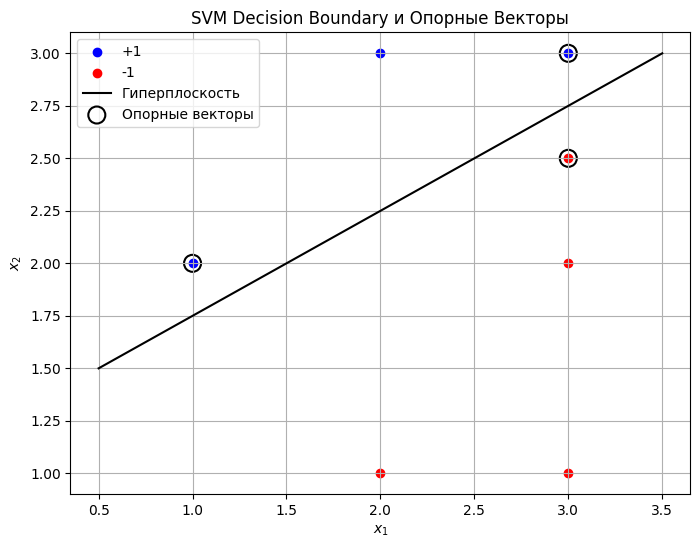

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Данные
X = np.array([[1, 2], [2, 3], [3, 3], [2, 1], [3, 1], [3, 2], [3, 2.5]])
y = np.array([1, 1, 1, -1, -1, -1, -1])

# Модель SVM с линейным ядром
svm_model = SVC(kernel='linear', C=1000)
svm_model.fit(X, y)

# Параметры гиперплоскости
w = svm_model.coef_[0]
b = svm_model.intercept_[0]

print(f'Гиперплоскость: {w[0]:.2f}*x₁ + {w[1]:.2f}*x₂ + {b:.2f} = 0')

fig, ax = plt.subplots(figsize=(8, 6))

# Отображаем точки двух классов
ax.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', label='+1')
ax.scatter(X[y==-1][:,0], X[y==-1][:,1], color='red', label='-1')

# Строим разделяющую гиперплоскость
x_plot = np.linspace(0.5, 3.5, 100)
y_plot = -(w[0]/w[1])*x_plot - b/w[1]
ax.plot(x_plot, y_plot, 'k-', label='Гиперплоскость')

# Опорные векторы
ax.scatter(svm_model.support_vectors_[:,0], svm_model.support_vectors_[:,1],
           s=150, linewidth=1.5, facecolors='none', edgecolors='k', label='Опорные векторы')

ax.legend()
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('SVM Decision Boundary и Опорные Векторы')
plt.grid()
plt.show()




### Результаты

На итоговом графике показаны:

- Точки двух классов: синие — класс `+1`, красные — класс `-1`.
- **Гиперплоскость** — белая линия, разделяющая классы.
- **Опорные векторы** — точки, расположенные ближе всего к границе. Они обведены белыми кружками и играют ключевую роль в построении разделяющей прямой.

Метод SVM стремится не только разделить классы, но и **максимизировать отступ (margin)** между ними, что повышает устойчивость модели.

### Вывод

Метод SVM успешно построил разделяющую гиперплоскость для линейно разделимых данных. Визуализация иллюстрирует выбор границы и подчёркивает значимость опорных векторов при обучении модели.

В данных присутствуют признаки перекрёстной чувствительности сенсоров, а также концептуального и сенсорного дрейфа, что описано в статье De Vito и др., Sens. and Act. B, Vol. 129, №2, 2008 (необходима ссылка на источник). Эти эффекты могут снижать точность оценки концентраций загрязняющих веществ по данным сенсоров. Пропущенные значения помечены как -200.